In [1]:
# !pip install openai
# !pip install pandas
# !pip install vllm
# !pip install scikit-learn
# !pip install distro

In [2]:
import perplexity_eval

In [3]:
import subprocess
import time
import requests

MODEL = "meta-llama/Llama-3.2-3B-Instruct"
SERVED_NAME = "llama-3.2-3b"
PORT = 8000

In [4]:
cmd = [
    "vllm", "serve",
    MODEL,
    "--served-model-name", SERVED_NAME,
    "--port", str(PORT),
    "--max-model-len", "8192",
    "--max-num-batched-tokens", "16384"
]

In [5]:
# This takes a second to run but you will see the output
print("Starting vLLM server...")
server_proc = subprocess.Popen(cmd)

Starting vLLM server...


In [ ]:
import os
import pandas as pd
os.environ["OPENAI_API_KEY"] = "not-needed"
data_path = "rag_decision_data.csv"
ENDPOINT = "http://" + "127.0.0.1:8000" + "/v1"
client = perplexity_eval.ChatCompletionClient(ENDPOINT)
df = pd.read_csv(data_path)
model_name = "llama-3.2-3b"
threshold = 1.3
predicted = []
req_count = 0
perplexity_scores = []

for _,row in df.iterrows():
    print(f"req_count: {req_count}")
    req_count += 1
    question = row["question"]
    label = row["rag_decision"]
    request = perplexity_eval.create_log_prob_request(question, model_name)
    log_probs = client.query_model_for_logprobs(request, model_name)
    perplexity = perplexity_eval.calculate_perplexity(log_probs)
    if perplexity > threshold:
        inferred_decision = 1
    else:
        inferred_decision = 0
    predicted.append(inferred_decision)
    perplexity_scores.append(perplexity)

req_count: 0


ValueError: Error calling chat completions: Connection error.

/home/evanzimm/.local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [ ]:
df["perplexity_decision"] = predicted
df["perplexity_score"] = perplexity_scores
perplexity_eval.calc_eval_metrics(df)
df.to_csv("perplexity_results.csv", index=False)

Accuracy: 0.66
Recall: 0.70
F1 Score: 0.68


In [7]:
results_df = pd.read_csv("perplexity_results.csv")

/home/evanzimm/.local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


INFO 12-13 22:18:23 [importing.py:44] Triton is installed but 0 active driver(s) found (expected 1). Disabling Triton to prevent runtime errors.
INFO 12-13 22:18:23 [importing.py:68] Triton not installed or not compatible; certain GPU-related functions will not be available.
WARNING 12-13 22:18:23 [interface.py:201] Failed to import from vllm._C: ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


results_df.head()

In [ ]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.2/113.2 kB 1.9 MB/s eta 0:00:0000:01
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.8 MB/s eta 0:00:00:00:0100:01
Using cached kiwisolver-1.4.9-cp312-cp312

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INFO 12-13 22:18:27 [scheduler.py:216] Chunked prefill is enabled with max_num_batched_tokens=2048.


Traceback (most recent call last):
  File "/home/evanzimm/.local/bin/vllm", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/home/evanzimm/.local/lib/python3.12/site-packages/vllm/entrypoints/cli/main.py", line 66, in main
    cmd.subparser_init(subparsers).set_defaults(dispatch_function=cmd.cmd)
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/evanzimm/.local/lib/python3.12/site-packages/vllm/entrypoints/cli/serve.py", line 72, in subparser_init
    serve_parser = make_arg_parser(serve_parser)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/evanzimm/.local/lib/python3.12/site-packages/vllm/entrypoints/openai/cli_args.py", line 278, in make_arg_parser
    parser = AsyncEngineArgs.add_cli_args(parser)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/evanzimm/.local/lib/python3.12/site-packages/vllm/engine/arg_utils.py", line 2078, in add_cli_args
    parser = EngineArgs.add_cli_args(parser)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 

In [ ]:
results_df = pd.read_csv("perplexity_results.csv")
results_df.head()

,title,question,rag_decision,subject,source_table,perplexity_decision,perplexity_score
0,Rule_of_law,"According to some, what is the rule of law is ...",1,NaN,NaN,1,1.319989
1,The_Sun_(United_Kingdom),What was the number of papers in the first pri...,1,NaN,NaN,0,1.281257
2,University_of_Kansas,When did the University of Kansas start issuin...,1,NaN,NaN,0,1.118718
3,Separation_of_church_and_state_in_the_United_S...,What did both houses of Congress pass measures...,1,NaN,NaN,1,1.565945
4,Canadian_football,What distance from the sidelines are hash mark...,1,NaN,NaN,0,1.237778


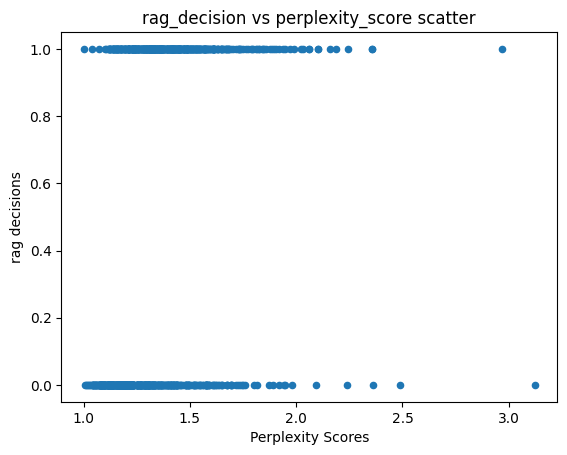

In [ ]:
results_df.plot.scatter(x='perplexity_score', y='rag_decision', title='rag_decision vs perplexity_score scatter')
plt.xlabel('Perplexity Scores')
plt.ylabel('rag decisions')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

thresholds = [1.0, 1.1, 1.2, 1.25, 1.3, 1.35, 1.4, 1.5]
for threshold in thresholds:
    print(f"Perplexity Threshold: {threshold}")
    predicted = results_df['perplexity_score'] >= threshold
    actual = results_df['rag_decision']
    
    accuracy = accuracy_score(actual, predicted)
    recall = recall_score(actual, predicted)
    f1 = f1_score(actual, predicted)

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print("---------------------")






Perplexity Threshold: 1.0
Accuracy: 0.50
Recall: 1.00
F1 Score: 0.67
---------------------
Perplexity Threshold: 1.1
Accuracy: 0.56
Recall: 0.99
F1 Score: 0.69
---------------------
Perplexity Threshold: 1.2
Accuracy: 0.65
Recall: 0.89
F1 Score: 0.72
---------------------
Perplexity Threshold: 1.25
Accuracy: 0.66
Recall: 0.78
F1 Score: 0.70
---------------------
Perplexity Threshold: 1.3
Accuracy: 0.66
Recall: 0.70
F1 Score: 0.68
---------------------
Perplexity Threshold: 1.35
Accuracy: 0.64
Recall: 0.56
F1 Score: 0.61
---------------------
Perplexity Threshold: 1.4
Accuracy: 0.62
Recall: 0.46
F1 Score: 0.55
---------------------
Perplexity Threshold: 1.5
Accuracy: 0.57
Recall: 0.26
F1 Score: 0.38
---------------------


Text(0.5, 1.0, 'Boxplot of Perplexity Score Grouped by RAG Decision')

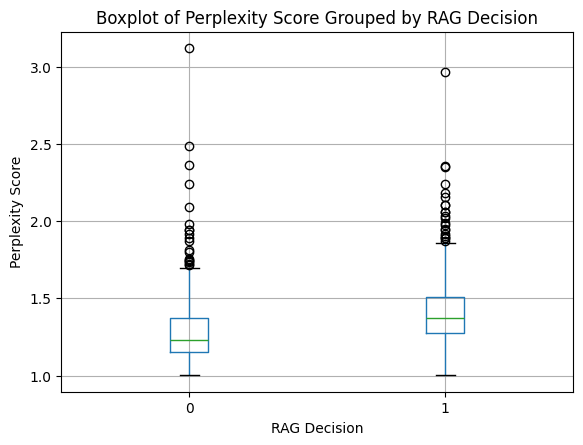

In [9]:
results_df.boxplot(column='perplexity_score', by='rag_decision', vert=True)
plt.ylabel("Perplexity Score")
plt.xlabel("RAG Decision")
plt.suptitle("")
plt.title("Boxplot of Perplexity Score Grouped by RAG Decision")

In [15]:
results_df.groupby("rag_decision")["perplexity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
rag_decision,,,,,,,,
0,500.0,1.290331,0.216980,1.005056,1.149661,1.229986,1.370293,3.122349
1,500.0,1.416657,0.219543,1.001038,1.272662,1.374965,1.511219,2.966955


In [21]:
!pip install seaborn
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 14.5 MB/s eta 0:00:00


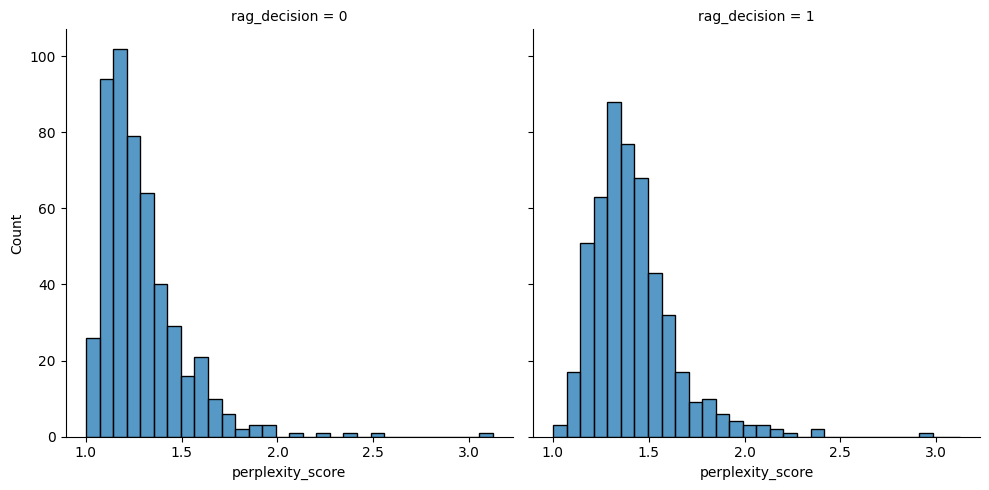

In [23]:
import seaborn as sns

sns.displot(
    data=results_df,
    x="perplexity_score",
    col="rag_decision",
    bins=30,
    kde=False,
    facet_kws={'sharex': True, 'sharey': True}
)
plt.show()